# CREMP Benchmark — Hybrid ΔPSA Validation

**Goal:** Validate the two-population chameleonicity model using physically-grounded membrane conformers.

**Strategy (Option C):**
- **Aqueous PSA** → vacuum ETKDGv3 max-PSA (existing pipeline, `feature_matrix.csv`)
- **Membrane PSA** → CREMP CHCl₃ Boltzmann-weighted mean-PSA (thermodynamic ensemble average at 298.15 K)
- **Hybrid ΔPSA** = vacuum aq-PSA − CREMP BW mean-PSA

**Test:** Does replacing the vacuum membrane conformer with a CREST CHCl₃ ensemble BW mean improve recovery of the chameleonic/rigid two-population signal vs CycPeptMPDB PAMPA permeability labels?

**Compounds:** CREMP × CycPeptMPDB overlap (SMILES-matched)

In [1]:
# ── Dependencies ───────────────────────────────────────────────────────────────
# Colab: uncomment below
# !pip install -q rdkit scikit-learn umap-learn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
RESULTS_DIR    = Path('../results')
CREMP_PSA_CSV  = RESULTS_DIR / 'cremp_deltapsa.csv'
FEATURE_MATRIX = RESULTS_DIR / 'feature_matrix.csv'

print('Paths set.')

Paths set.


## 1. Load Data

In [2]:
# ── CREMP ΔPSA (CHCl₃ conformers) ─────────────────────────────────────────────
cremp = pd.read_csv(CREMP_PSA_CSV, low_memory=False)
cremp = cremp[cremp['error'].isna()].copy()
print(f'CREMP compounds (clean): {len(cremp)}')
print(f'Columns: {list(cremp.columns)}')
cremp.head(3)

CREMP compounds (clean): 2457
Columns: ['compound_id', 'smiles', 'n_confs', 'temperature_K', 'aq_psa3d', 'mem_psa3d', 'delta_psa3d', 'psa3d_std', 'psa3d_spread', 'bw_psa3d', 'norm_delta_psa', 'tpsa_2d', 'ensemble_energy', 'pop_lowest_pct', 'unique_confs', 'error']


,compound_id,smiles,n_confs,temperature_K,aq_psa3d,mem_psa3d,delta_psa3d,psa3d_std,psa3d_spread,bw_psa3d,norm_delta_psa,tpsa_2d,ensemble_energy,pop_lowest_pct,unique_confs,error
0,meA.L.bHph.P.L.F,CC(C)C[C@@H]1NC(=O)[C@H](C)N(C)C(=O)[C@H](Cc2c...,1774.0,298.15,91.4925,37.1453,54.3472,9.8861,54.3472,69.2052,0.060804,157.02,0.404,42.658,1774.0,NaN
1,Me_Tza.3Pal.dP.PhPr_Gly.Nva(Ph).Me_dF,CN1C(=O)[C@H](CCCc2ccccc2)NC(=O)CN(CCCc2ccccc2...,5743.0,298.15,164.4337,114.6035,49.8302,10.4136,49.8302,130.4510,0.043122,165.22,0.912,10.730,5743.0,NaN
2,meA.Bn_Gly.Bn_Gly.P.Bn_Gly.F,C[C@H]1C(=O)N(Cc2ccccc2)CC(=O)N(Cc2ccccc2)CC(=...,345.0,298.15,101.8672,58.4506,43.4166,9.2845,43.4166,81.6670,0.044406,130.65,0.467,15.657,345.0,NaN


In [3]:
# ── CycPeptMPDB feature matrix ─────────────────────────────────────────────────
fm = pd.read_csv(FEATURE_MATRIX, low_memory=False)
print(f'CycPeptMPDB compounds: {len(fm)}')
print(f'Permeable: {fm["permeable"].sum()} | Impermeable: {(fm["permeable"]==0).sum()}')

fm_keep = ['ID', 'SMILES_canonical', 'permeable', 'PAMPA', 'MolWt',
           'Monomer_Length', 'aq_psa3d', 'mem_psa3d', 'delta_psa3d',
           'psa3d_std', 'psa3d_spread']
fm_keep = [c for c in fm_keep if c in fm.columns]
fm = fm[fm_keep].copy()
fm.head(3)

CycPeptMPDB compounds: 7298
Permeable: 4848 | Impermeable: 2450


,ID,SMILES_canonical,permeable,PAMPA,MolWt,Monomer_Length,aq_psa3d,mem_psa3d,delta_psa3d,psa3d_std,psa3d_spread
0,1,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,0,-6.6,1202.635,11,179.8730,94.9961,84.8769,25.106231,84.8769
1,2,CC(C)C[C@@H]1NC(=O)[C@@H](CC(C)C)NC(=O)[C@@H](...,0,-6.2,712.933,6,156.7600,92.3353,64.4247,14.757505,64.4247
2,3,CC(C)C[C@H]1NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@...,0,-7.0,712.933,6,142.6448,95.8376,46.8072,16.035785,46.8072


## 2. SMILES Matching — CREMP × CycPeptMPDB Overlap

In [4]:
def canonical_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(str(smi))
        return Chem.MolToSmiles(mol) if mol else None
    except Exception:
        return None

print('Canonicalizing SMILES...')
cremp['canon_smi'] = cremp['smiles'].apply(canonical_smiles)
fm['canon_smi']    = fm['SMILES_canonical'].apply(canonical_smiles)

print(f'CREMP valid SMILES:       {cremp["canon_smi"].notna().sum()} / {len(cremp)}')
print(f'CycPeptMPDB valid SMILES: {fm["canon_smi"].notna().sum()} / {len(fm)}')

Canonicalizing SMILES...
CREMP valid SMILES:       2457 / 2457
CycPeptMPDB valid SMILES: 7298 / 7298


In [5]:
# ── Inner join on canonical SMILES ────────────────────────────────────────────
merged_raw = pd.merge(
    cremp.dropna(subset=['canon_smi']),
    fm.dropna(subset=['canon_smi']),
    on='canon_smi',
    how='inner',
    suffixes=('_cremp', '_vac')
)

print(f'Raw merge rows:     {len(merged_raw)}')
print(f'Unique canon_smi:   {merged_raw["canon_smi"].nunique()}')
n_inflated = len(merged_raw) - merged_raw['canon_smi'].nunique()
print(f'Inflated rows (CycPeptMPDB duplicate SMILES with conflicting labels): {n_inflated}')

# ── Deduplicate: keep first CycPeptMPDB row per SMILES ────────────────────────
# CycPeptMPDB has 54 canonical SMILES appearing 2-6 times (different sources,
# sometimes conflicting permeable labels for same molecule). The inner join
# inflates by 19 rows. Deduplicate by keeping the first occurrence per SMILES
# to ensure one-compound-one-row — required for valid AUC computation.
merged = merged_raw.drop_duplicates(subset='canon_smi', keep='first').copy()
print(f'\nAfter deduplication: {len(merged)} compounds')
print(f'Permeable: {merged["permeable"].sum()} | Impermeable: {(merged["permeable"]==0).sum()}')

# ── Hybrid ΔPSA ───────────────────────────────────────────────────────────────
# aq-PSA: vacuum ETKDGv3 max-PSA (most extended conformer in vacuum)
# mem-PSA: CREMP Boltzmann-weighted mean PSA (thermodynamic average in CHCl₃)
# This is the most physically defensible hybrid: extreme aq state vs ensemble avg in membrane
merged['hybrid_delta_psa'] = merged['aq_psa3d_vac'] - merged['bw_psa3d']

print(f'\nHybrid ΔPSA: {merged["hybrid_delta_psa"].min():.1f} – {merged["hybrid_delta_psa"].max():.1f} Å²  (mean={merged["hybrid_delta_psa"].mean():.1f})')
print(f'Vacuum ΔPSA: {merged["delta_psa3d_vac"].min():.1f} – {merged["delta_psa3d_vac"].max():.1f} Å²  (mean={merged["delta_psa3d_vac"].mean():.1f})')

Raw merge rows:     2435
Unique canon_smi:   2416
Inflated rows (CycPeptMPDB duplicate SMILES with conflicting labels): 19

After deduplication: 2416 compounds
Permeable: 1578 | Impermeable: 838

Hybrid ΔPSA: -1.3 – 128.7 Å²  (mean=47.5)
Vacuum ΔPSA: 21.2 – 120.6 Å²  (mean=50.9)


Monomer_Length distribution:
                                   Overlap   Non-overlap
n compounds                           2435          4863
mean                                  6.55          8.74
median                                 7.0          10.0
min                                      6             2
max                                     10            15

Overlap    >= 9 residues:    9 /  2435  (0.4%)
Non-overlap >= 9 residues: 2834 /  4863  (58.3%)

Mann-Whitney U (overlap vs non-overlap Monomer_Length): p = 0.00e+00

Interpretation:
  The CREMP overlap is 6.5-mer on average.
  Only 0.4% of overlap compounds reach the >=9 residue chameleonic threshold.
  The non-overlap (untested) compounds average 8.7 residues,
  with 58.3% at >=9 residues — this is where ΔPSA should have signal.


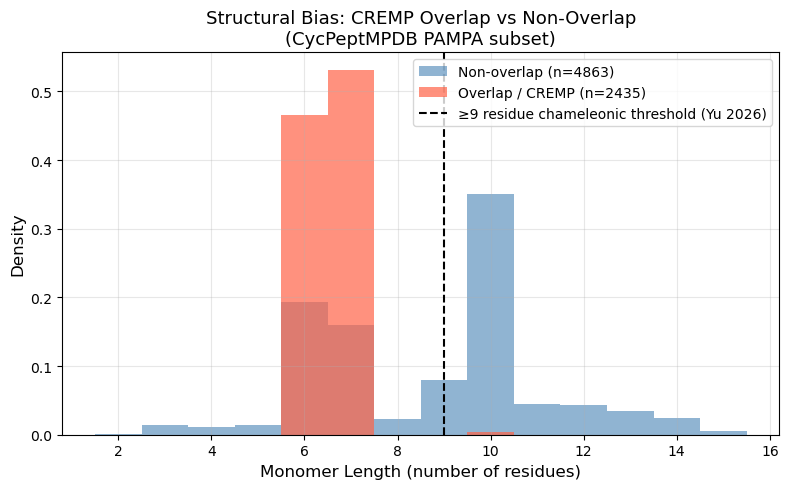

In [6]:
# ── Structural Bias QC ────────────────────────────────────────────────────────
# Critical check: CREMP compounds are DEL cyclic hexapeptides (6-7 mers).
# Chameleonic switching requires >=9 residues (Yu et al. 2026).
# If the overlap is dominated by small peptides, ΔPSA cannot be expected to predict
# permeability — not because ΔPSA is wrong, but because the test set is below the
# size threshold where the mechanism operates.

overlap_smis    = set(merged['canon_smi'])
fm_all          = pd.read_csv(FEATURE_MATRIX, low_memory=False)
fm_all['canon_smi'] = fm_all['SMILES_canonical'].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(str(s))) if Chem.MolFromSmiles(str(s)) else None
)
fm_overlap    = fm_all[fm_all['canon_smi'].isin(overlap_smis)]
fm_nonoverlap = fm_all[~fm_all['canon_smi'].isin(overlap_smis)]

print('Monomer_Length distribution:')
print(f'{"":30s}  {"Overlap":>10s}  {"Non-overlap":>12s}')
print(f'{"n compounds":30s}  {len(fm_overlap):>10d}  {len(fm_nonoverlap):>12d}')
print(f'{"mean":30s}  {fm_overlap["Monomer_Length"].mean():>10.2f}  {fm_nonoverlap["Monomer_Length"].mean():>12.2f}')
print(f'{"median":30s}  {fm_overlap["Monomer_Length"].median():>10.1f}  {fm_nonoverlap["Monomer_Length"].median():>12.1f}')
print(f'{"min":30s}  {fm_overlap["Monomer_Length"].min():>10.0f}  {fm_nonoverlap["Monomer_Length"].min():>12.0f}')
print(f'{"max":30s}  {fm_overlap["Monomer_Length"].max():>10.0f}  {fm_nonoverlap["Monomer_Length"].max():>12.0f}')
print()

n_ov_large    = (fm_overlap['Monomer_Length'] >= 9).sum()
n_nov_large   = (fm_nonoverlap['Monomer_Length'] >= 9).sum()
pct_ov_large  = n_ov_large  / len(fm_overlap)  * 100
pct_nov_large = n_nov_large / len(fm_nonoverlap) * 100
print(f'Overlap    >= 9 residues: {n_ov_large:4d} / {len(fm_overlap):5d}  ({pct_ov_large:.1f}%)')
print(f'Non-overlap >= 9 residues: {n_nov_large:4d} / {len(fm_nonoverlap):5d}  ({pct_nov_large:.1f}%)')
print()

# Mann-Whitney test on Monomer_Length
u_stat, p_mw = stats.mannwhitneyu(
    fm_overlap['Monomer_Length'].dropna(),
    fm_nonoverlap['Monomer_Length'].dropna(),
    alternative='two-sided'
)
print(f'Mann-Whitney U (overlap vs non-overlap Monomer_Length): p = {p_mw:.2e}')
print()
print('Interpretation:')
print(f'  The CREMP overlap is {fm_overlap["Monomer_Length"].mean():.1f}-mer on average.')
print(f'  Only {pct_ov_large:.1f}% of overlap compounds reach the >=9 residue chameleonic threshold.')
print(f'  The non-overlap (untested) compounds average {fm_nonoverlap["Monomer_Length"].mean():.1f} residues,')
print(f'  with {pct_nov_large:.1f}% at >=9 residues — this is where ΔPSA should have signal.')

# ── Plot Monomer_Length distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
bins = range(2, 17)
ax.hist(fm_nonoverlap['Monomer_Length'].dropna(), bins=bins, alpha=0.6, color='steelblue',
        label=f'Non-overlap (n={len(fm_nonoverlap)})', density=True, align='left')
ax.hist(fm_overlap['Monomer_Length'].dropna(), bins=bins, alpha=0.7, color='tomato',
        label=f'Overlap / CREMP (n={len(fm_overlap)})', density=True, align='left')
ax.axvline(9, color='k', lw=1.5, ls='--', label='≥9 residue chameleonic threshold (Yu 2026)')
ax.set_xlabel('Monomer Length (number of residues)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Structural Bias: CREMP Overlap vs Non-Overlap\n(CycPeptMPDB PAMPA subset)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'cremp_structural_bias.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Membrane Conformer: Vacuum vs CREMP CHCl₃

In [7]:
sub = merged[['mem_psa3d_vac', 'bw_psa3d', 'permeable']].dropna()
r, _ = stats.pearsonr(sub['mem_psa3d_vac'], sub['bw_psa3d'])
diff = sub['bw_psa3d'] - sub['mem_psa3d_vac']
mae  = np.abs(diff).mean()
frac_cremp_lower = (diff < 0).mean()

print(f'Pearson r (vacuum min-PSA vs CREMP BW mean-PSA): {r:.3f}')
print(f'MAE:                                              {mae:.1f} Å²')
print(f'CREMP BW mean lower than vacuum min:              {frac_cremp_lower*100:.1f}% of cases')
print(f'Mean diff (CREMP BW − vacuum min):                {diff.mean():.1f} ± {diff.std():.1f} Å²')
print()
print('Interpretation:')
if diff.mean() < -5:
    print('  CREMP ensemble average is lower than vacuum min — vacuum over-collapses.')
elif diff.mean() > 5:
    print('  CREMP BW mean is higher than vacuum min — vacuum finds more extreme collapsed conformers.')
else:
    print('  CREMP BW mean and vacuum min-PSA largely agree.')

Pearson r (vacuum min-PSA vs CREMP BW mean-PSA): 0.599
MAE:                                              11.6 Å²
CREMP BW mean lower than vacuum min:              42.2% of cases
Mean diff (CREMP BW − vacuum min):                3.4 ± 14.4 Å²

Interpretation:
  CREMP BW mean and vacuum min-PSA largely agree.


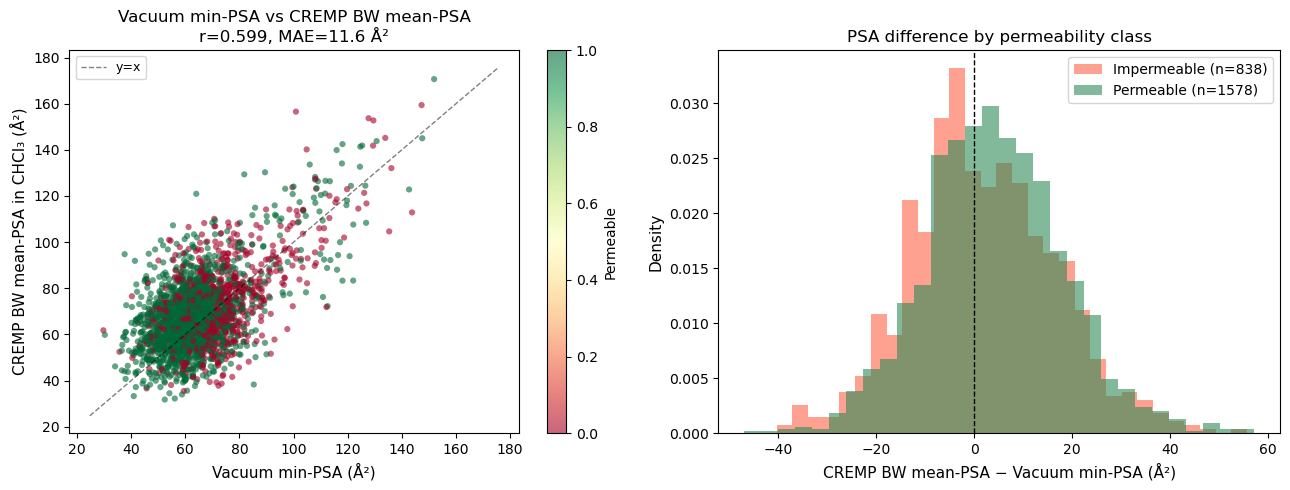

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(sub['mem_psa3d_vac'], sub['bw_psa3d'],
                c=sub['permeable'], cmap='RdYlGn', alpha=0.6, s=20, linewidths=0)
lo = min(sub['mem_psa3d_vac'].min(), sub['bw_psa3d'].min()) - 5
hi = max(sub['mem_psa3d_vac'].max(), sub['bw_psa3d'].max()) + 5
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='y=x')
ax.set_xlabel('Vacuum min-PSA (Å²)', fontsize=11)
ax.set_ylabel('CREMP BW mean-PSA in CHCl₃ (Å²)', fontsize=11)
ax.set_title(f'Vacuum min-PSA vs CREMP BW mean-PSA\nr={r:.3f}, MAE={mae:.1f} Å²', fontsize=12)
plt.colorbar(sc, ax=ax, label='Permeable')
ax.legend(fontsize=9)

ax = axes[1]
perm_diff   = diff[sub['permeable'] == 1]
imperm_diff = diff[sub['permeable'] == 0]
ax.hist(imperm_diff, bins=30, alpha=0.6, color='tomato',   label=f'Impermeable (n={len(imperm_diff)})', density=True)
ax.hist(perm_diff,   bins=30, alpha=0.6, color='seagreen', label=f'Permeable (n={len(perm_diff)})',     density=True)
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel('CREMP BW mean-PSA − Vacuum min-PSA (Å²)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('PSA difference by permeability class', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'cremp_membrane_conformer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Two-Population Test — AUC Comparison

In [9]:
df_auc = merged[['permeable', 'delta_psa3d_vac', 'hybrid_delta_psa', 'psa3d_spread_cremp', 'bw_psa3d']].dropna(subset=['permeable', 'delta_psa3d_vac', 'hybrid_delta_psa'])

auc_results = {}
for col, label, invert in [
    ('delta_psa3d_vac',    'Vacuum ΔPSA (ETKDGv3)              ', False),
    ('hybrid_delta_psa',   'Hybrid ΔPSA (vac aq / CREMP BW mem)', False),
    ('psa3d_spread_cremp', 'CREMP PSA spread (CHCl₃ only)      ', False),
    ('bw_psa3d',           'CREMP BW mean-PSA (CHCl₃, inverted)', True),
]:
    tmp = df_auc[['permeable', col]].dropna()
    if len(tmp) < 10:
        continue
    score = -tmp[col] if invert else tmp[col]
    auc = roc_auc_score(tmp['permeable'], score)
    auc_results[label.strip()] = auc
    note = ' [inverted — lower BW PSA → permeable]' if invert else ''
    print(f'{label}  AUC = {auc:.3f}{note}')

print(f'\nn = {len(df_auc)} overlap compounds')
print('\nNote: bw_psa3d AUC is reported after inversion (lower CHCl₃ BW mean-PSA → predict permeable).')

Vacuum ΔPSA (ETKDGv3)                AUC = 0.499
Hybrid ΔPSA (vac aq / CREMP BW mem)  AUC = 0.454
CREMP PSA spread (CHCl₃ only)        AUC = 0.412
CREMP BW mean-PSA (CHCl₃, inverted)  AUC = 0.607 [inverted — lower BW PSA → permeable]

n = 2416 overlap compounds

Note: bw_psa3d AUC is reported after inversion (lower CHCl₃ BW mean-PSA → predict permeable).


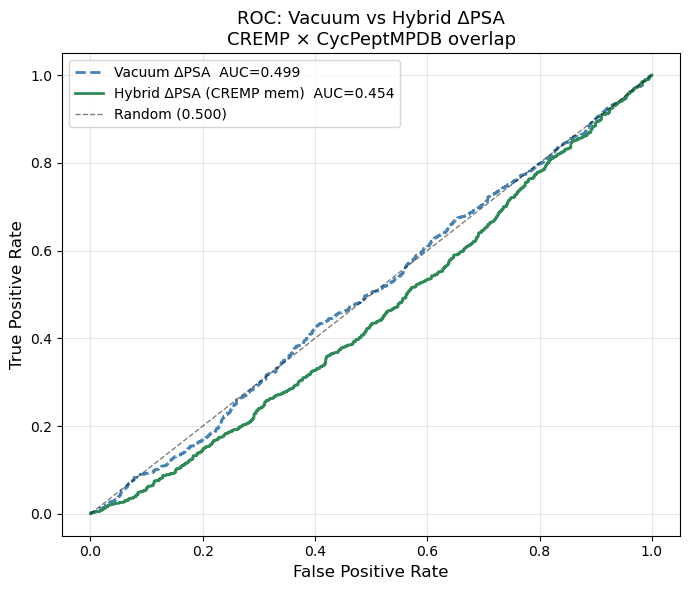

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for col, label, color, ls in [
    ('delta_psa3d_vac',  'Vacuum ΔPSA',            'steelblue', '--'),
    ('hybrid_delta_psa', 'Hybrid ΔPSA (CREMP mem)', 'seagreen',  '-'),
]:
    tmp = df_auc[['permeable', col]].dropna()
    if len(tmp) < 10:
        continue
    fpr, tpr, _ = roc_curve(tmp['permeable'], tmp[col])
    auc = roc_auc_score(tmp['permeable'], tmp[col])
    ax.plot(fpr, tpr, color=color, ls=ls, lw=2, label=f'{label}  AUC={auc:.3f}')

ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random (0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC: Vacuum vs Hybrid ΔPSA\nCREMP × CycPeptMPDB overlap', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'cremp_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Two-Population Distributions

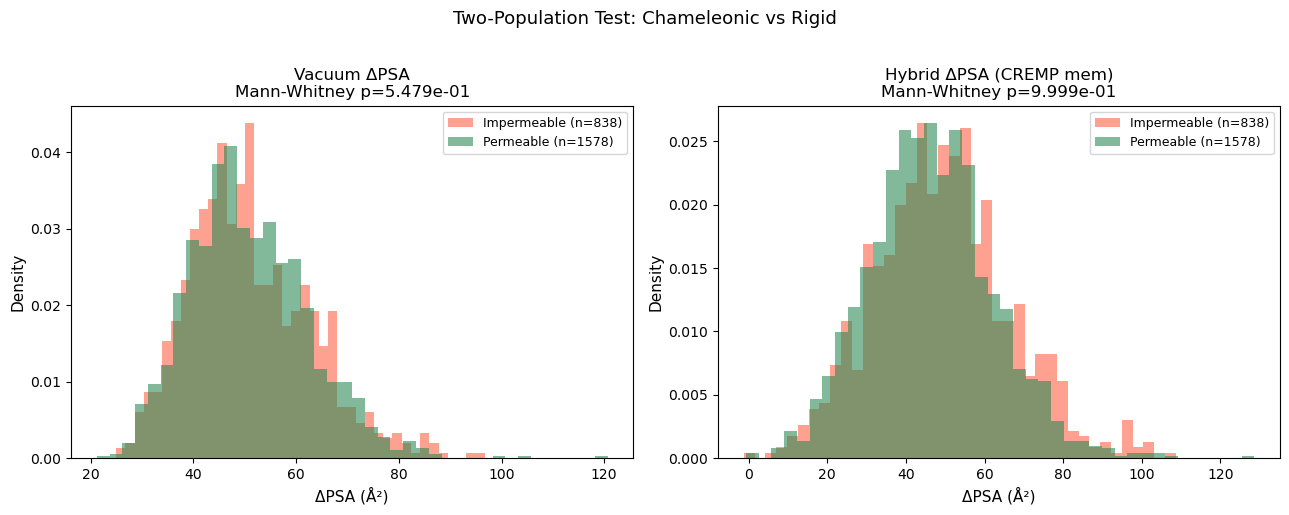

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

perm   = merged[merged['permeable'] == 1]
imperm = merged[merged['permeable'] == 0]

for ax, col, title in [
    (axes[0], 'delta_psa3d_vac',  'Vacuum ΔPSA'),
    (axes[1], 'hybrid_delta_psa', 'Hybrid ΔPSA (CREMP mem)'),
]:
    ax.hist(imperm[col].dropna(), bins=40, alpha=0.6, color='tomato',
            density=True, label=f'Impermeable (n={len(imperm[col].dropna())})')
    ax.hist(perm[col].dropna(),   bins=40, alpha=0.6, color='seagreen',
            density=True, label=f'Permeable (n={len(perm[col].dropna())})')
    u, p_val = stats.mannwhitneyu(perm[col].dropna(), imperm[col].dropna(), alternative='greater')
    ax.set_xlabel('ΔPSA (Å²)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}\nMann-Whitney p={p_val:.3e}', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Two-Population Test: Chameleonic vs Rigid', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'cremp_two_population.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [12]:
print('=' * 65)
print('CREMP BENCHMARK SUMMARY')
print('=' * 65)
print(f'CREMP compounds processed:       {len(cremp)}')
print(f'CycPeptMPDB compounds:           {len(fm)}')
print(f'Overlap (SMILES-matched):        {len(merged)}')
print(f'  Permeable:                     {merged["permeable"].sum()}')
print(f'  Impermeable:                   {(merged["permeable"]==0).sum()}')
print()
print('Membrane conformer quality (CHCl₃ vs vacuum):')
print(f'  Pearson r:                     {r:.3f}')
print(f'  MAE:                           {mae:.1f} Å²')
print(f'  CREMP finds lower mem-PSA:     {frac_cremp_lower*100:.1f}% of cases')
print()
print('AUC (PAMPA permeability):')
for label, auc in auc_results.items():
    print(f'  {label:45s} {auc:.3f}')
print()
print('Interpretation:')
hybrid_key = 'Hybrid ΔPSA (vac aq / CREMP BW mem)'
vacuum_key  = 'Vacuum ΔPSA (ETKDGv3)'
if hybrid_key in auc_results and vacuum_key in auc_results:
    delta_auc = auc_results[hybrid_key] - auc_results[vacuum_key]
    if delta_auc > 0.01:
        print(f'  CREMP BW mem-PSA improves AUC by +{delta_auc:.3f}')
        print('  Physically-grounded membrane conformer recovers better signal.')
    elif delta_auc < -0.01:
        print(f'  Vacuum mem-PSA outperforms CREMP BW by {-delta_auc:.3f}.')
        print('  CHCl₃ ensemble BW mean may dilute the collapsed-state signal vs vacuum min-PSA.')
    else:
        print(f'  AUC difference negligible ({delta_auc:+.3f}).')
        print('  PAMPA label noise dominates both signals — conformer quality is not the bottleneck.')
else:
    print('  WARNING: expected AUC keys not found — check cell-12 label strings.')

CREMP BENCHMARK SUMMARY
CREMP compounds processed:       2457
CycPeptMPDB compounds:           7298
Overlap (SMILES-matched):        2416
  Permeable:                     1578
  Impermeable:                   838

Membrane conformer quality (CHCl₃ vs vacuum):
  Pearson r:                     0.599
  MAE:                           11.6 Å²
  CREMP finds lower mem-PSA:     42.2% of cases

AUC (PAMPA permeability):
  Vacuum ΔPSA (ETKDGv3)                         0.499
  Hybrid ΔPSA (vac aq / CREMP BW mem)           0.454
  CREMP PSA spread (CHCl₃ only)                 0.412
  CREMP BW mean-PSA (CHCl₃, inverted)           0.607

Interpretation:
  Vacuum mem-PSA outperforms CREMP BW by 0.045.
  CHCl₃ ensemble BW mean may dilute the collapsed-state signal vs vacuum min-PSA.
